In [25]:
import libpysal
from esda.moran import Moran_Local_BV
from pyprojroot import here
import geopandas as gpd
import matplotlib.pyplot as plt

In [27]:
# 1. Data loading
ROOT = here()
DATA_DIR = ROOT / "data" / "london_lsoa_education_accessibility.gpkg"
OUTPUTS_DIR = ROOT / "outputs"

gdf = gpd.read_file(DATA_DIR)

In [19]:
# Fill unreachable travel times (NaN) with a high penalty value (120min to represent severe inaccessibility).
gdf_clean = gdf.copy()
gdf_clean['tt_transit_nearest_outstanding'] = gdf_clean['tt_transit_nearest_outstanding'].fillna(120)

# Drop any rows missing core variables or geometries to prevent spatial matrix errors
gdf_clean = gdf_clean.dropna(subset=['tt_transit_nearest_outstanding', 'idaci_score', 'geometry'])

In [20]:
# 2. Create Spatial Weights Matrix
# Using K-Nearest Neighbors (KNN, k=8) instead of Queen contiguity avoid issues from River Thames
w = libpysal.weights.KNN.from_dataframe(gdf_clean, k=8)
w.transform = 'r'

In [22]:
# 3. Define the two variables for bivariate correlation
# Variable X: Public Transit Travel Time (Higher = Worse access)
x = gdf_clean['tt_transit_nearest_outstanding'].values
# Variable Y: IDACI score (Higher = More deprived)
y = gdf_clean['idaci_score'].values

In [23]:
# 4. Calculate Bivariate Local Moran's I
# This tests whether an LSOA with high travel time is spatially surrounded 
# by neighboring LSOAs with high child poverty.
moran_bv = Moran_Local_BV(x, y, w)

In [24]:
# Get the LISA results 

## get the LISA for every lsoa
print("Local Moran's I values (first 5):", moran_bv.Is[:5])

## check the quadrant for every lsoa
print("Quadrants (first 5):", moran_bv.q[:5])

## check the pseudo p-value to check statisitcal significance
print("Pseudo p-values (first 5):", moran_bv.p_sim[:5])

## calculate how many lsoas are statistically significant
sig_count = (moran_bv.p_sim < 0.05).sum()
print(f"Number of statistically significant LSOAs: {sig_count}")

Local Moran's I values (first 5): [-0.04946487  0.0018004   0.17141641 -0.51907526 -0.49459232]
Quadrants (first 5): [4 1 1 2 2]
Pseudo p-values (first 5): [0.256 0.223 0.058 0.009 0.026]
Number of statistically significant LSOAs: 2308


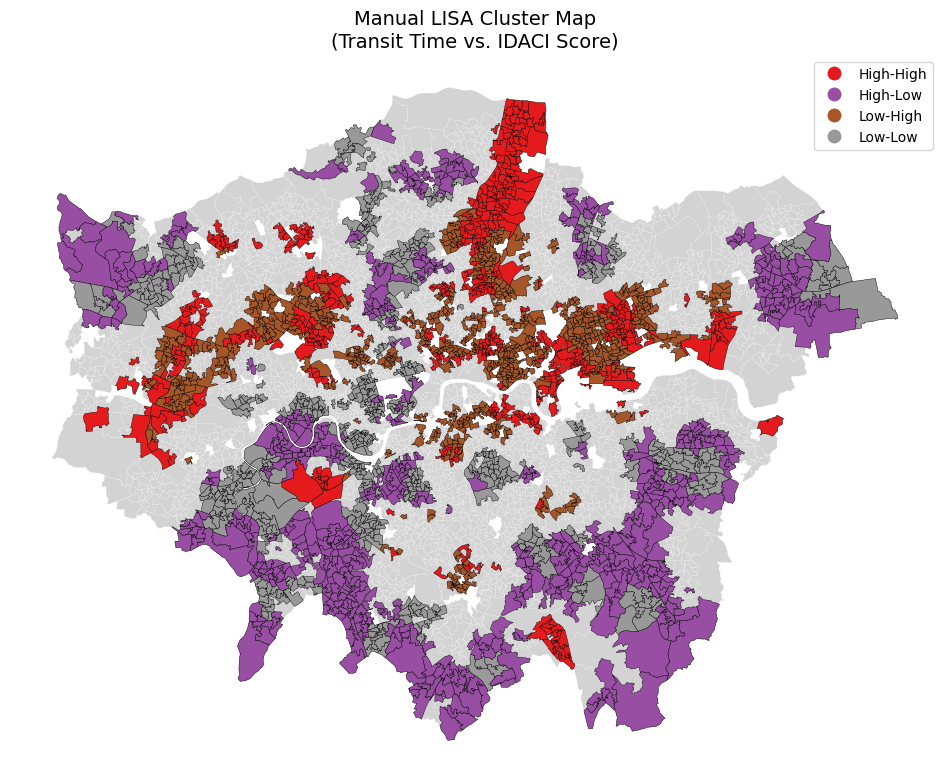

In [28]:
# 5. Plot the LISA (Local Indicators of Spatial Association) Cluster Map

# use p-value = 0.05 as a cut-off
p_cutoff = 0.05
labels = {1: 'High-High', 2: 'Low-High', 3: 'Low-Low', 4: 'High-Low'}
colors = {1: 'red', 2: 'lightblue', 3: 'blue', 4: 'pink'}

# get a new cluster as "not significant"
gdf_clean['lisa_cluster'] = 'Not Significant'

# label every lsoa with a for loop
for i in range(len(gdf_clean)):
    if moran_bv.p_sim[i] < p_cutoff:
        quadrant = moran_bv.q[i]
        gdf_clean.iloc[i, gdf_clean.columns.get_loc('lisa_cluster')] = labels[quadrant]

# make the plot
fig, ax = plt.subplots(figsize=(12, 10))
gdf_clean.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.1)
color_list = [colors[k] for k, v in labels.items() if v in gdf_clean['lisa_cluster'].unique()]
gdf_clean[gdf_clean['lisa_cluster'] != 'Not Significant'].plot(
    column='lisa_cluster',
    ax=ax,
    legend=True,
    categorical=True,
    cmap='Set1', 
    edgecolor='black',
    linewidth=0.3
)

ax.set_title("Manual LISA Cluster Map\n(Transit Time vs. IDACI Score)", fontsize=14)
ax.set_axis_off()

plt.savefig(OUTPUTS_DIR / "figures" / "manual_lisa_map.png", dpi=300)
plt.show()

#### Discussion

This Bivariate LISA (Local Indicators of Spatial Association) Cluster Map illustrates the spatial correlation between public transit travel time to 'Outstanding' schools and child deprivation (IDACI Score) across London LSOAs.

- High-High Clusters (Red): In these areas, high levels of child deprivation coincide with significantly poor accessibility to high-performing schools. These clusters are primarily concentrated in Outer London boroughs, indicating a systemic spatial mismatch where the most vulnerable children are also the most geographically excluded.

- Low-Low Clusters (Blue): These are predominantly located in central and western parts of London. These areas benefit from a "double advantage": low deprivation levels and excellent public transport connectivity to top-tier educational resources.

- The map reveals that educational exclusion is __not randomly distributed__ but is __geographically concentrated__. The pink (High-Low) and light blue (Low-High) clusters further highlight the complexity of London's urban structure, showing wealthy peripheral areas and accessible but deprived inner-city pockets.

- The identification of High-High clusters provides a data-driven roadmap for policy intervention. These specific zones require urgent attention, such as the strategic expansion of school bus networks or the prioritisation of new high-quality school placements to break the cycle of spatial and educational inequality.